# Audio Sentiment Classification using CNN

**This notebook is part of Digital Egypt Builders Initative Artificial Intelligence Track Teaching Materials**

## Task Overview

Build a **Convolutional Neural Network (CNN)** to classify audio sentiment into 3 classes:
- **Positive**
- **Negative**
- **Neutral**

### Dataset

[Audio Speech Sentiment](https://www.kaggle.com/datasets/imsparsh/audio-speech-sentiment)
### What You Will Do
1. Build a Conv1D CNN architecture
2. Train the model with callbacks
3. Evaluate using accuracy, precision, recall, F1-score, and confusion matrix

## 1. Setup and Imports

In [4]:
!pip install resampy librosa -q

In [5]:
# Core libraries
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# Audio processing
import librosa

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Warnings suppression
import warnings
warnings.filterwarnings('ignore')

# Random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [6]:
# Load dataset from Kaggle
train_data = pd.read_csv('/kaggle/input/datasets/imsparsh/audio-speech-sentiment/TRAIN.csv')
train_path = '/kaggle/input/datasets/imsparsh/audio-speech-sentiment/TRAIN'

print("Dataset shape:", train_data.shape)
print("\nFirst few rows:")
print(train_data.head())
print("\nClass distribution:")
print(train_data['Class'].value_counts())

Dataset shape: (250, 2)

First few rows:
  Filename     Class
0  346.wav  Negative
1  163.wav   Neutral
2  288.wav  Negative
3  279.wav  Negative
4  244.wav  Negative

Class distribution:
Class
Negative    87
Positive    82
Neutral     81
Name: count, dtype: int64


## 2. Audio Preprocessing

**Feature Extraction Approach:**
- Load audio files from TRAIN.csv metadata
- Extract MFCC (Mel-Frequency Cepstral Coefficients) - 128 coefficients
- Take mean across time axis to create a single feature vector per audio
- Result: 1D feature vector of 128 values per audio file

### 2.1 Feature extraction function

In [7]:
def extract_features(audio_path):
    """Extract MFCC features from audio file."""
    audio, sample_rate = librosa.load(audio_path, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=128)
    return np.mean(mfccs.T, axis=0)

### 2.2 Load all audio files and extract features

In [8]:
def load_data(data, path):
    """Load all audio files and extract MFCC features."""
    features, target = [], []
    for index, row in tqdm(data.iterrows(), desc="Loading audio files"):
        audio_path = os.path.join(path, row['Filename'])
        features.append(extract_features(audio_path))
        target.append(row['Class'])
    return np.array(features), np.array(target)

# Extract features from all training audio
X, y = load_data(train_data, train_path)
print(f"Loaded {len(X)} training samples")
print(f"Feature shape: {X.shape}")

Loading audio files: 250it [00:38,  6.43it/s]

Loaded 250 training samples
Feature shape: (250, 128)


### 2.3 Encode labels and split data

In [9]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(f"Classes: {encoder.classes_}")

# Add channel dimension
X = np.expand_dims(X, axis=-1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Classes: ['Negative' 'Neutral' 'Positive']
X_train: (200, 128, 1), X_test: (50, 128, 1)
y_train: (200,), y_test: (50,)


## 3. Baseline for Comparison

In [10]:
# Least performing model predictions based on majority class 
baseline_accuracy = max(np.bincount(y_train)) / len(y_train)
print(f"Baseline accuracy (majority class): {baseline_accuracy:.2%}")

Baseline accuracy (majority class): 34.50%


## 4. TODO: Build Your CNN Model

**Task:** Build a Conv1D CNN with the following requirements:
- Input shape: (128, 1)
- Output: 3 classes (softmax)
- At least: Conv1D → MaxPooling1D → Flatten → Dense → Dropout → Output

In [11]:
num_class = len(encoder.classes_)

model = keras.Sequential([
    # USE this format in synatx (keras.layers."layername(params)")
    keras.layers.Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(128, 1)),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(filters=128, kernel_size=3, activation="relu"),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(num_class, activation="softmax"),
])


model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


2026-04-02 21:43:25.256009: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 516,995 (1.97 MB)

 Trainable params: 516,995 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

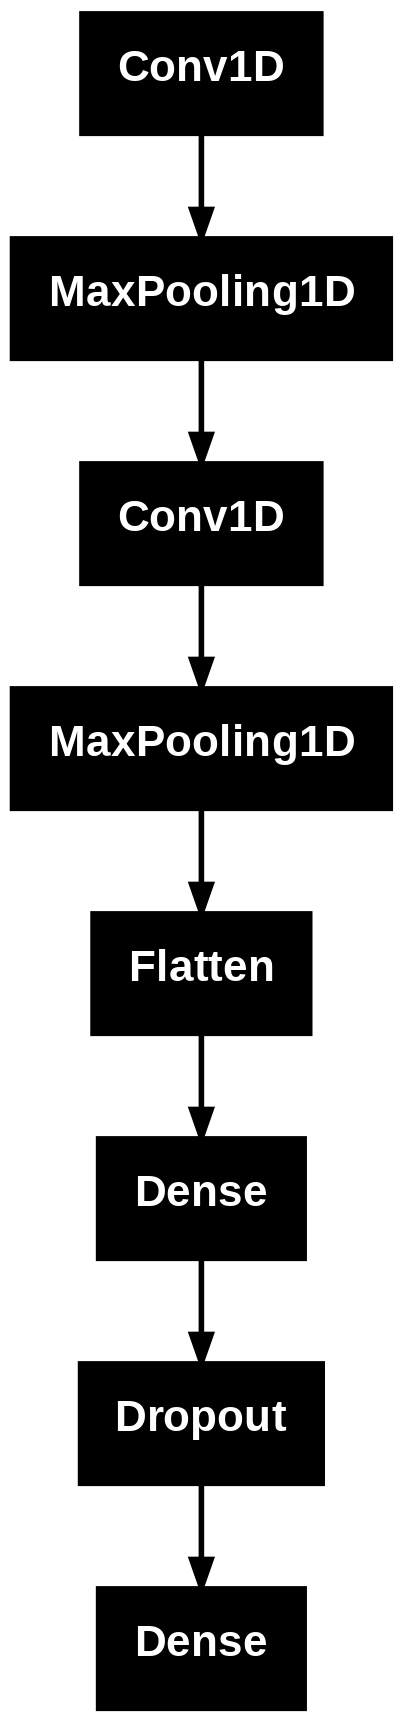

In [12]:
# Vizualize the model sequence
keras.utils.plot_model(model=model)

## 5. TODO: Train Your Model

Use EarlyStopping and ModelCheckpoint callbacks to save the best model.

In [13]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

save_point = keras.callbacks.ModelCheckpoint(
    'audio.keras', save_best_only=True, verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stopping, save_point],
    verbose=1
)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3842 - loss: 4.5717
Epoch 1: val_loss improved from inf to 2.11722, saving model to audio.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.3920 - loss: 4.5441 - val_accuracy: 0.3750 - val_loss: 2.1172
Epoch 2/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 1.8593
Epoch 2: val_loss improved from 2.11722 to 0.64612, saving model to audio.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5025 - loss: 1.9124 - val_accuracy: 0.6250 - val_loss: 0.6461
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7220 - loss: 0.7827
Epoch 3: val_loss did not improve from 0.64612
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7141 - loss: 0.7935 - val_accuracy: 0.6500 - val_loss: 0.6956
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6270 - loss: 0.7743
Epoch 4: val_loss improved from 0.64612 to 0.59418, saving model to audio.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - ac

### 5.1 Plot training curves (after training)

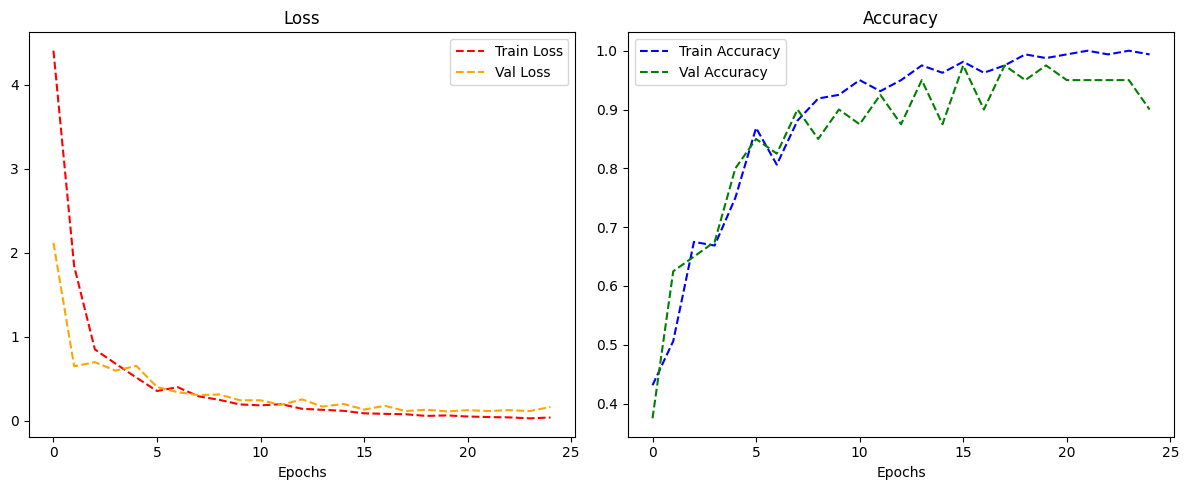

In [14]:
hist = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['loss'], '--', color='red', label='Train Loss')
plt.plot(hist['val_loss'], '--', color='orange', label='Val Loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epochs')

plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], '--', color='blue', label='Train Accuracy')
plt.plot(hist['val_accuracy'], '--', color='green', label='Val Accuracy')
plt.legend()
plt.title('Accuracy')
plt.xlabel('Epochs')

plt.tight_layout()
plt.show()


## 6. TODO: Evaluate on Test Set

In [15]:
# Load best model and make predictions
model = keras.models.load_model('audio.keras')

# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9392 - loss: 0.1190 
Test Loss: 0.1141
Test Accuracy: 0.9400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


### Compute evaluation metrics

In [16]:
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

# Overall accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Precision, Recall, F1
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\nPrecision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")



TEST SET EVALUATION
Accuracy: 0.9400 (94.00%)

Precision (Macro): 0.9524
Precision (Weighted): 0.9486
Recall (Macro): 0.9375
Recall (Weighted): 0.9400
F1-Score (Macro): 0.9399
F1-Score (Weighted): 0.9392


### Detailed per-class metrics

In [17]:
print(f"\n{'='*50}")
print("CLASSIFICATION REPORT")
print(f"{'='*50}")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))



CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.86      1.00      0.92        18
     Neutral       1.00      1.00      1.00        16
    Positive       1.00      0.81      0.90        16

    accuracy                           0.94        50
   macro avg       0.95      0.94      0.94        50
weighted avg       0.95      0.94      0.94        50



### Confusion matrix visualization

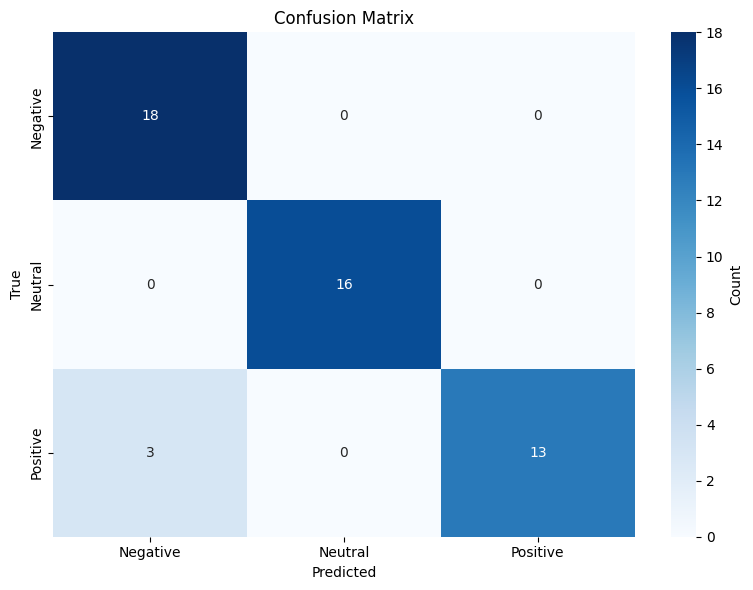


Confusion Matrix - Interpretation:
  Diagonal: Correct predictions
  Off-diagonal: Misclassifications


In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix - Interpretation:")
print(f"  Diagonal: Correct predictions")
print(f"  Off-diagonal: Misclassifications")


## 7. Key Concepts Explained

### A. What is MFCC?

**MFCC = Mel-Frequency Cepstral Coefficients**

MFCCs are a compact representation of audio that captures the most important information for human hearing:

- **Why MFCC?** Raw audio has millions of data points. MFCCs compress it to just 128 values per file while preserving emotion/sentiment cues.
- **How it works:**
  1. Convert audio → frequency domain (FFT)
  2. Apply mel scale (matches human hearing: we hear low frequencies better)
  3. Take logarithm (humans perceive loudness logarithmically)
  4. Apply DCT (Discrete Cosine Transform) to get final coefficients
  
- **Result:** 128 numbers that represent the audio's "fingerprint"
- **Computation:** Takes ~2-3 seconds per audio file (reasonable for Kaggle)

**Example:** A 3-second audio clip → 1 MFCC vector of 128 values instead of 48,000 raw samples

### B. Understanding `model.fit()`, `EarlyStopping`, and `ModelCheckpoint`

#### 1. `model.fit()` parameters:

```python
history = model.fit(
    X_train, y_train,              # Training data and labels
    epochs=30,                     # Number of full passes through data
    validation_split=0.2,          # 20% of train data for validation
    callbacks=[...],               # Special functions during training
    verbose=1                      # Print progress (0=silent, 1=detailed)
)
```

**What happens:**
- Epoch 1: Train on 80% data, validate on 20%
- Epoch 2: Same, update weights
- ... Repeat 30 times or until EarlyStopping triggers

---

#### 2. `EarlyStopping` — Stop training when validation loss stops improving:

```python
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',            # Watch validation loss
    patience=5,                    # Wait 5 epochs if no improvement
    restore_best_weights=True,     # Restore weights from epoch with best val_loss
    verbose=1                      # Print when it stops
)
```

**Why?**
- Training forever → **overfitting** (memorizes training data)
- EarlyStopping → stops when the model stops learning
- Saves time & improves generalization

**Example:**
```
Epoch 10: val_loss=0.450  Best so far
Epoch 11: val_loss=0.460  Worse
Epoch 12: val_loss=0.455  Worse
Epoch 13: val_loss=0.458  Worse
Epoch 14: val_loss=0.460  Worse
Epoch 15: val_loss=0.462  Patience exhausted → STOP
```

---

#### 3. `ModelCheckpoint` — Save the best model during training:

```python
save_point = keras.callbacks.ModelCheckpoint(
    'audio.keras',                 # Save to this file
    monitor='val_loss',            # Track validation loss
    save_best_only=True,           # Only save if it's the best
    verbose=1                      # Print save messages
)
```

**Why?**
- If training crashes, you still have the best model so far
- You can load it later for prediction: `model = keras.models.load_model('audio.keras')`
- Insurance against losing your best weights

---

#### Combined workflow:

```
Epoch 1  → val_loss: 0.800 → Save model (best so far)
Epoch 2  → val_loss: 0.600 → Save model (better)
Epoch 3  → val_loss: 0.450 → Save model (even better!)
Epoch 4  → val_loss: 0.460 → Don't save (worse)
Epoch 5  → val_loss: 0.455 → Don't save
Epoch 6  → val_loss: 0.458 → Don't save
Epoch 7  → val_loss: 0.460 → Don't save (5 epochs without improvement)
          → EarlyStopping triggers!
          → Restore weights from Epoch 3 (best model)
          → Use 'audio.keras' file for predictions
```

### C. Why Conv1D and Not Conv2D?

**Data structure matters:**

```
Conv2D (2D Convolution):
- Used for: Images (height × width × channels)
- Our data: (batch, 128, 1) - just a 1D sequence
- 2D kernels would be wasteful

Conv1D (1D Convolution):
- Used for: Time series, sequences, audio
- Our data: (batch, 128, 1) - MFCC features over time
- Kernel slides along the 128-dimension only
- Efficient: learns patterns in sequential features
```

**Analogy:**
- **Conv2D:** Like scanning an image with a 2D filter (detecting edges, shapes)
- **Conv1D:** Like scanning a heartbeat signal with a 1D filter (detecting patterns over time)

MFCCs are already a compressed 1D representation, so Conv1D is perfect—it learns how different MFCC features relate to emotion without unnecessary 2D operations.

### D. What is `res_type` (scipy vs kaiser_fast)?

**res_type = resampling type** — How librosa converts audio to a standard sample rate (16 kHz)

```python
librosa.load(audio_path, res_type='scipy')  
librosa.load(audio_path, res_type='kaiser_fast')
```

| Parameter | Speed | Quality | Dependency |
|-----------|-------|---------|------------|
| **'scipy'** | Slower | Good | scipy (always installed) |
| **'kaiser_fast'** | Fast | Excellent | resampy (must install) |

**Why do we resample?**
- Audio files have different sample rates (44.1 kHz, 48 kHz, 16 kHz, etc.)
- We need all audio to be the same rate (16 kHz) to extract consistent MFCC features
- Resampling: convert any sample rate → 16 kHz

### E. What is TQDM?

**tqdm = "taqaddum" (Arabic: progress)**

TQDM adds a progress bar to loops:

```python
from tqdm import tqdm

for index, row in tqdm(data.iterrows(), desc="Loading audio files"):
    # Do something...
```

**Output example:**
```
Loading audio files: 45%|████▌     | 450/1000 [02:30<03:15, 2.82it/s]
```

**Why use it?**
- Shows progress (45% done)
- Estimated time remaining (3:15 seconds left)
- Speed indicator (2.82 iterations/second)
- Prevents thinking the process is frozen

**In our notebook:**
- Extracting 1000+ MFCC features takes 5-10 minutes
- Without TQDM, you'd stare at a blank screen
- With TQDM, you see live progress and ETA

### F. What is `np.expand_dims` and Why Do We Use It?

**expand_dims = add a new dimension to an array**

```python
X = np.expand_dims(X, axis=-1)
```

**Before:**
```
X.shape = (1000, 128)  
         (samples, features)
```

**After:**
```
X.shape = (1000, 128, 1)
         (samples, features, channels)
```

**Why?**
- **Conv1D expects:** (batch, steps, channels)
- **We had:** (batch, 128) - missing the channel dimension
- **We added:** 1 channel (grayscale-like, single stream of data)

**Analogy:**
- Conv1D is like reading a mono audio file (1 channel)
- Conv1D is like reading a mono image (1 channel = grayscale)
- If we had stereo audio, we'd have 2 channels (left + right)

Without this dimension, the CNN wouldn't know how to process the data.

### G. Weighted vs Macro Evaluation Metrics

When you compute **Precision**, **Recall**, and **F1-Score**, you need to aggregate results across all 3 classes. Two common approaches:

#### Understanding the Difference

**Macro Average:**
- Treats all classes equally (unweighted)
- Formula: Average(metric_class1, metric_class2, metric_class3)
- Best for: Balanced datasets, when you care equally about each class

**Weighted Average:**
- Weights each class by how many samples it has
- Formula: (metric_class1 × count_class1 + metric_class2 × count_class2 + ...) / total_samples
- Best for: Imbalanced datasets, when rare classes shouldn't dominate the score

#### Example with Sentiment Data

Imagine test set results:

| Class | Samples | Precision | Recall |
|-------|---------|-----------|--------|
| Negative | 100 | 0.90 | 0.85 |
| Neutral | 300 | 0.85 | 0.88 |
| Positive | 100 | 0.95 | 0.92 |

**Macro Precision:**
```
(0.90 + 0.85 + 0.95) / 3 = 0.867
Each class contributes equally (1/3 weight each)
```

**Weighted Precision:**
```
(0.90 × 100 + 0.85 × 300 + 0.95 × 100) / 500 = 0.870
Neutral class (300 samples) dominates the score
```

#### When to Use Which?

| Scenario | Use | Why |
|----------|-----|-----|
| **Balanced classes** (each ~100 samples) | Either | Similar results—doesn't matter much |
| **Imbalanced classes** (300 vs 50 vs 50) | Weighted | Shows real-world performance |
| **Want equal importance** | Macro | Sentiment/Negative equally important |
| **Want true accuracy** | Weighted | Reflects actual test distribution |

**Read as:**
- `macro`: "Average of all 3 classes (ignoring sample count)"
- `weighted`: "Average accounting for class frequency in test set"

#### Key Insight

- **Macro:** "How well does the model do on Positive, Negative, Neutral **on average**?"
- **Weighted:** "What's the overall accuracy considering the real test distribution?"

If your model gets **Macro F1: 0.85** but **Weighted F1: 0.92**, it means:
-  Performs well on all classes equally
-  But rare classes don't pull down the weighted score much (test has few of them)

## References

* [Noor Saeed /audio-speech-sentiment-analysis](https://www.kaggle.com/code/noorsaeed/audio-speech-sentiment-analysis-using-cnn-deep-lng)
* [Ahmed Ashraf Ahmed /audio-sentiment-analysis](https://www.kaggle.com/code/ahmedashrafahmed/audio-sentiment-analysis)
* [Keras Docs](https://keras.io/api/)
* [Deep Learning for Audio Classification by Seth Adams](https://youtube.com/playlist?list=PLhA3b2k8R3t2Ng1WW_7MiXeh1pfQJQi_P&si=x7KrAqejWsZPSWXJ)

# Thank You Dears 
 Good Luck <3